# Sydney Housing Price Prediction and Decision Support System

## Part 2: Data Understanding and Feature Engineering

This section continues with the dataset from Part 1, 114 sold properties across Paddington, Marrickville, and Blacktown. In this section I look through the distributions, check for weird outliers, look at whether suburbs actually differ the way I originally expected, and figure out how to handle the missing values before any modelling happens.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
np.random.seed(42)

## 2.1 Loading the data and a first look

First I check shape, dtypes, and which values are actually missing before moving on to the next step.

In [2]:
df = pd.read_csv('sydney_housing_final.csv')
print('shape:', df.shape)
df.head()

shape: (114, 11)


,suburb,address,sale_price,sale_date,property_type,bedrooms,bathrooms,parking_spaces,land_size_sqm,agent_description_snippet,listing_url
0,Paddington,"17/24 Gordon Street, Paddington",1480000,31 Aug 2026,Apartment,1,1.0,NaN,78.0,NaN,https://www.realestate.com.au/sold/property-ap...
1,Paddington,"49 Hopetoun Street, Paddington",3820000,28 Aug 2026,Terrace,4,2.0,NaN,113.8,NaN,https://www.realestate.com.au/sold/property-te...
2,Paddington,"54 Stewart Street, Paddington",3965000,27 Aug 2026,House,4,1.0,1.0,NaN,NaN,https://www.realestate.com.au/sold/property-ho...
3,Paddington,"4/4 Underwood Street, Paddington",1385000,26 Aug 2026,Apartment,2,1.0,NaN,73.0,NaN,https://www.realestate.com.au/sold/property-ap...
4,Paddington,"2/54A Hopewell Street, Paddington",380000,24 Aug 2026,Studio,1,NaN,NaN,NaN,NaN,https://www.realestate.com.au/sold/property-st...


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114 entries, 0 to 113
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   suburb                     114 non-null    object 
 1   address                    114 non-null    object 
 2   sale_price                 114 non-null    int64  
 3   sale_date                  114 non-null    object 
 4   property_type              114 non-null    object 
 5   bedrooms                   114 non-null    int64  
 6   bathrooms                  112 non-null    float64
 7   parking_spaces             75 non-null     float64
 8   land_size_sqm              49 non-null     float64
 9   agent_description_snippet  0 non-null      float64
 10  listing_url                22 non-null     object 
dtypes: float64(4), int64(2), object(5)
memory usage: 9.9+ KB


In [4]:
print('missing values per column:')
print(df.isna().sum())
print()
print('missing % per column:')
print((df.isna().mean() * 100).round(1))

missing values per column:
suburb                         0
address                        0
sale_price                     0
sale_date                      0
property_type                  0
bedrooms                       0
bathrooms                      2
parking_spaces                39
land_size_sqm                 65
agent_description_snippet    114
listing_url                   92
dtype: int64

missing % per column:
suburb                         0.0
address                        0.0
sale_price                     0.0
sale_date                      0.0
property_type                  0.0
bedrooms                       0.0
bathrooms                      1.8
parking_spaces                34.2
land_size_sqm                 57.0
agent_description_snippet    100.0
listing_url                   80.7
dtype: float64


`agent_description_snippet` is empty for every row, I did not collect that field since it is the optional advanced text-feature extension and I decided to focus on the core requirements. I will remove that column completely.

`listing_url` is missing on 92 of 114 rows. I only collected source links for a verification sample (about 20% of rows) instead of every listing, since the URL does not feed into any model, it was purely so I could spot-check the scraped data against the live site. I will leave this column as is and will not try to fill it, it is not a modelling feature.

`land_size_sqm` is missing on 57% of rows, `parking_spaces` on 34%, and `bathrooms` on a small 2 rows. All three actually matter for modelling, so I will deal with each properly below, once I have checked whether the gaps are random or linked to something such as property type.

In [5]:
df = df.drop(columns=['agent_description_snippet'])
df['sale_date'] = pd.to_datetime(df['sale_date'], format='%d %b %Y')
df.head()

,suburb,address,sale_price,sale_date,property_type,bedrooms,bathrooms,parking_spaces,land_size_sqm,listing_url
0,Paddington,"17/24 Gordon Street, Paddington",1480000,2026-08-31,Apartment,1,1.0,NaN,78.0,https://www.realestate.com.au/sold/property-ap...
1,Paddington,"49 Hopetoun Street, Paddington",3820000,2026-08-28,Terrace,4,2.0,NaN,113.8,https://www.realestate.com.au/sold/property-te...
2,Paddington,"54 Stewart Street, Paddington",3965000,2026-08-27,House,4,1.0,1.0,NaN,https://www.realestate.com.au/sold/property-ho...
3,Paddington,"4/4 Underwood Street, Paddington",1385000,2026-08-26,Apartment,2,1.0,NaN,73.0,https://www.realestate.com.au/sold/property-ap...
4,Paddington,"2/54A Hopewell Street, Paddington",380000,2026-08-24,Studio,1,NaN,NaN,NaN,https://www.realestate.com.au/sold/property-st...


## 2.2 Class distribution across the three suburbs

I first check the property count for each suburb and whether the split meets the target (30+ each).

suburb
Paddington      50
Marrickville    32
Blacktown       32
Name: count, dtype: int64



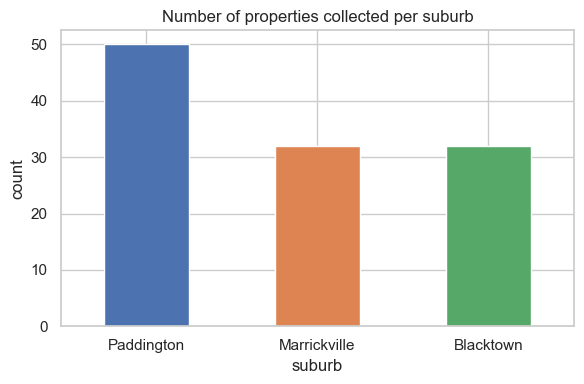

In [6]:
print(df['suburb'].value_counts())
print()
df['suburb'].value_counts().plot(kind='bar', figsize=(6,4), color=['#4C72B0','#DD8452','#55A868'])
plt.title('Number of properties collected per suburb')
plt.ylabel('count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Paddington has more (50) than the other two (32 each) mainly because I continued collecting pages while the extraction was running smoothly and did not stop exactly at 30. It is not a problem for the minimum requirement, but this does mean Paddington has a bit more pull on any pooled statistics unless I keep this in mind to look at things suburb by suburb too, which I do throughout this section.

## 2.3 Price distribution, overall and by suburb

This is the main section. Sale price is the target variable here, so I want to understand its shape before moving further. I check whether it is skewed, are there wild outliers, and whether the pattern changes between suburbs.

In [7]:
print(df['sale_price'].describe())

count    1.140000e+02
mean     1.658706e+06
std      1.142538e+06
min      3.750000e+05
25%      8.200000e+05
50%      1.345000e+06
75%      2.233750e+06
max      5.500000e+06
Name: sale_price, dtype: float64


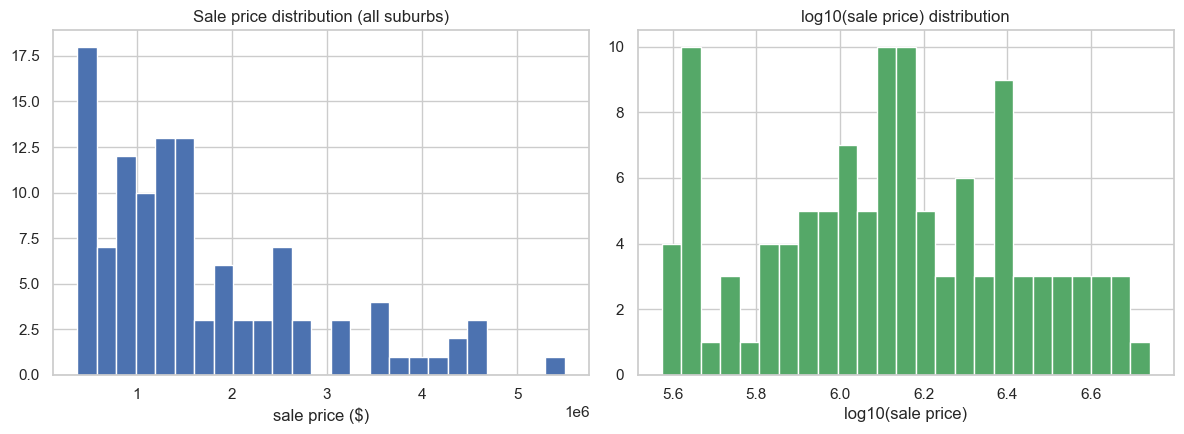

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
axes[0].hist(df['sale_price'], bins=25, color='#4C72B0', edgecolor='white')
axes[0].set_title('Sale price distribution (all suburbs)')
axes[0].set_xlabel('sale price ($)')

axes[1].hist(np.log10(df['sale_price']), bins=25, color='#55A868', edgecolor='white')
axes[1].set_title('log10(sale price) distribution')
axes[1].set_xlabel('log10(sale price)')
plt.tight_layout()
plt.show()

The raw price distribution is right-skewed, which is reasonable, there is a hard floor around a few hundred thousand but no clear upper ceiling, and a small number of multi-million dollar houses extend the upper tail. The log version looks much closer to symmetric, so a log transform of the target is an option worth testing when I get to modelling in Part 3, a lot of regression methods assume roughly normal, constant-variance residuals, and that is a lot more plausible on the log scale here.

/var/folders/t7/r080bp2119l0r8ckrdj0nd3r0000gn/T/ipykernel_81107/279031801.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='suburb', y='sale_price', order=['Blacktown','Marrickville','Paddington'],


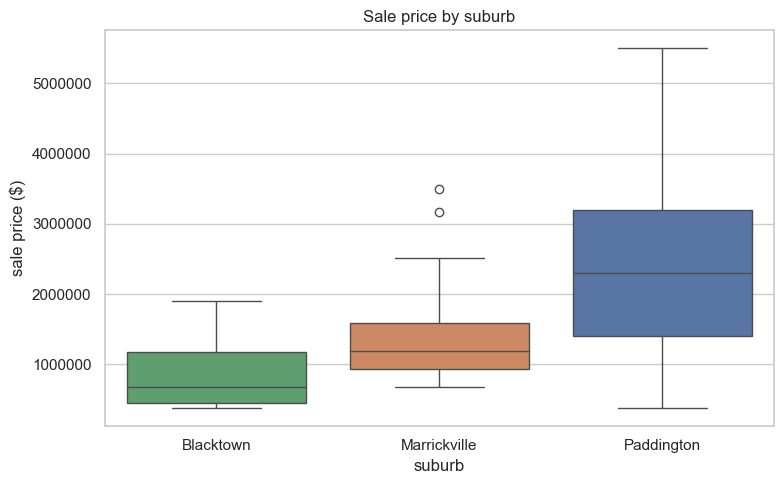

              count         mean     median           std       min        max
suburb                                                                        
Blacktown      32.0   825921.875   675000.0  4.354798e+05  375000.0  1900000.0
Marrickville   32.0  1377625.000  1186000.0  6.787720e+05  675000.0  3500000.0
Paddington     50.0  2371580.000  2305000.0  1.255333e+06  380000.0  5500000.0


In [9]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='suburb', y='sale_price', order=['Blacktown','Marrickville','Paddington'],
            palette=['#55A868','#DD8452','#4C72B0'])
plt.title('Sale price by suburb')
plt.ylabel('sale price ($)')
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()

print(df.groupby('suburb')['sale_price'].describe()[['count','mean','50%','std','min','max']]
      .rename(columns={'50%':'median'}))

This is the main contrast I wanted from these three suburbs. Blacktown has a median of $675K with a tighter and lower-variance spread. Marrickville falls between them at $1.19M with more spread. Paddington is both the highest (median $2.3M) and also has the widest spread, it ranges from a $380K studio to a $5.5M house.

The boxes barely overlap between suburbs, which is a good sign for modelling, suburb alone is already doing a lot of the work in separating these prices.

## 2.4 Trends over time

I first check the actual date range, and then check whether prices changed across that period, because if they did, I would then need to consider whether `sale_date` itself should be a feature.

In [10]:
df['sale_month'] = df['sale_date'].dt.to_period('M')

print('date range:', df['sale_date'].min().date(), 'to', df['sale_date'].max().date())
print('span:', (df['sale_date'].max() - df['sale_date'].min()).days, 'days')
print()
print('sales per month, by suburb:')
print(pd.crosstab(df['sale_month'], df['suburb']))

date range: 2026-02-28 to 2026-09-14
span: 198 days

sales per month, by suburb:
suburb      Blacktown  Marrickville  Paddington
sale_month                                     
2026-02             0             0           2
2026-03             0             0          10
2026-04             0             0           9
2026-05             0             0          10
2026-06             0             0           6
2026-07             0             0           4
2026-08            17            21           9
2026-09            15            11           0


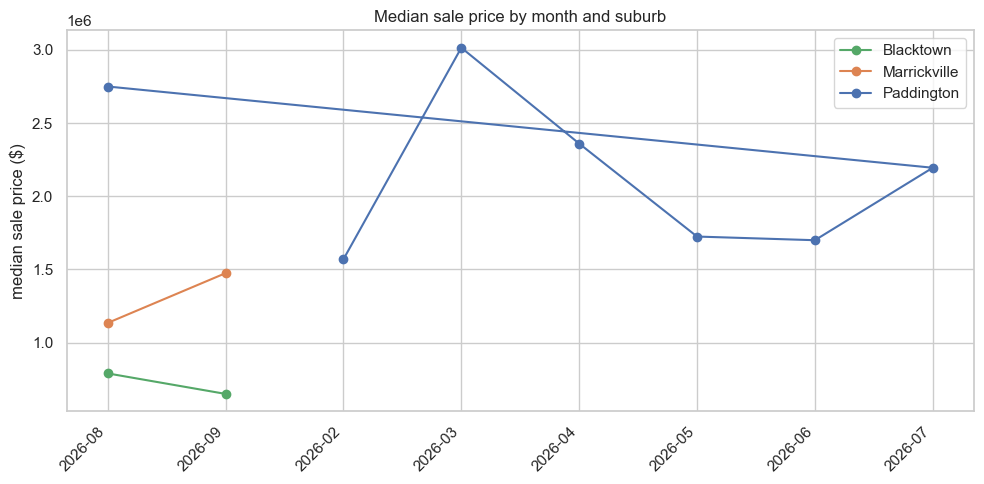

In [11]:
df['sale_month'] = df['sale_date'].dt.to_period('M')
monthly = df.groupby(['sale_month','suburb'])['sale_price'].median().reset_index()
monthly['sale_month'] = monthly['sale_month'].astype(str)

plt.figure(figsize=(10,5))
for suburb, color in zip(['Blacktown','Marrickville','Paddington'], ['#55A868','#DD8452','#4C72B0']):
    sub = monthly[monthly['suburb']==suburb]
    plt.plot(sub['sale_month'], sub['sale_price'], marker='o', label=suburb, color=color)
plt.xticks(rotation=45, ha='right')
plt.ylabel('median sale price ($)')
plt.title('Median sale price by month and suburb')
plt.legend()
plt.tight_layout()
plt.show()

This is not just random noise, it is a genuine structural issue with the way the data was collected. The date range is only 198 days (28 Feb to 14 Sep 2026), instead of the roughly 12 months I originally expected. More importantly, suburb and sale month are strongly confounded: Paddingtonly has sales from Feb through Aug (nothing in Sep), while Blacktown and Marrickville only have sales in Aug and Sep. This happened because I pulled two full pages for Paddington (50 rows) but stopped at roughly one page for the other two suburbs (32 rows each), and since results are sorted most recent first, a lower-volume suburb like Paddington needed to reach further back in time to fill the same number of rows, while the higher-turnover suburbs stayed wilimited the last few weeks.

The practical consequence is that `sale_date` (or any month/season feature built from it) cannot be used safely as a model input in Part 3, right now it would act almost entirely as a suburb identifier in disguise instead of capturing any genuine time trend, since knowing the month would let a model correctly guess Paddington vs the other two suburbs most of the time. I am leaving `sale_date` and `sale_month` out of the feature set for modelling and treating this as an honest limitation of the manual collection process instead of something to paper over, it is the kind of thing worth naming directly in Part 1s discussion of dataset quality and limitations.

## 2.5 Outliers and unusual observations

I use the IQR method separately wilimited each suburb (because an outlier can mean something different in Blacktown than in Paddington, a $1.9M Blacktown house is a genuine extreme, but that same price would be totally ordinary in Paddington).

In [12]:
def iqr_outliers(group):
    q1, q3 = group['sale_price'].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    return group[(group['sale_price'] < lower) | (group['sale_price'] > upper)]

outliers = df.groupby('suburb', group_keys=False).apply(iqr_outliers, include_groups=False)
outliers_full = df.loc[outliers.index]
print(f'{len(outliers_full)} outliers found out of {len(df)} rows')
outliers_full[['suburb','address','sale_price','bedrooms','bathrooms','property_type']]

2 outliers found out of 114 rows


,suburb,address,sale_price,bedrooms,bathrooms,property_type
51,Marrickville,"11 Albermarle Street, Marrickville",3170000,3,1.0,House
55,Marrickville,"124 Warren Road, Marrickville",3500000,5,3.0,House


Only 2 outliers by this method, and both are Marrickville houses (11 Albermarle Street at $3.17M and 124 Warren Road at $3.5M). This was a little unexpected, I originally expected Paddington to throw up the most outliers because it has the widest price range, but that is actually why it does not, Paddingtons whole distribution is naturally spread out, so its IQR is wide enough that even the $5.5M house does not clear the outlier threshold wilimited that suburb. Marrickville is much tighter overall, so two unusually large houses stand out more sharply there by comparison.

Neither of these looks like a data entry error when I check them against bedrooms/bathrooms, they are both large houses (3 bed/1 bath and the other has more beds and baths) which is consistent with a bigger, more expensive property, not a typo. I am keeping both in instead of removing it them, they are real market variation. Part 4 later asks me to dig into the worst prediction errors specifically, so keeping unusual points in now is more useful than cutting them here.

## 2.6 Missing value handling

Before choosing how to fill `land_size_sqm`, `parking_spaces`, and `bathrooms`, I first check whether the gaps are random or linked to something such as property type, because that affects which fill value makes sense.

In [13]:
print('land_size_sqm missing rate by property type (%):')
print((df.groupby('property_type')['land_size_sqm'].apply(lambda x: x.isna().mean())*100).round(0))
print()
print('parking_spaces missing rate by property type (%):')
print((df.groupby('property_type')['parking_spaces'].apply(lambda x: x.isna().mean())*100).round(0))
print()
print('rows missing bathrooms:')
print(df[df['bathrooms'].isna()][['suburb','address','property_type','bedrooms','bathrooms']])

land_size_sqm missing rate by property type (%):
property_type
Apartment     64.0
House         47.0
Studio       100.0
Terrace       71.0
Townhouse     50.0
Unit          44.0
Name: land_size_sqm, dtype: float64

parking_spaces missing rate by property type (%):
property_type
Apartment     18.0
House         49.0
Studio       100.0
Terrace       71.0
Townhouse      0.0
Unit          11.0
Name: parking_spaces, dtype: float64

rows missing bathrooms:
        suburb                            address property_type  bedrooms  \
4   Paddington  2/54A Hopewell Street, Paddington        Studio         1   
34  Paddington  4/54a Hopewell Street, Paddington        Studio         1   

    bathrooms  
4         NaN  
34        NaN  


In [14]:
print('parking_spaces median among rows that HAVE a value, by property type:')
print(df.groupby('property_type')['parking_spaces'].median())

parking_spaces median among rows that HAVE a value, by property type:
property_type
Apartment    1.0
House        1.5
Studio       NaN
Terrace      1.0
Townhouse    1.0
Unit         1.0
Name: parking_spaces, dtype: float64


The three columns show different patterns, so I handle each one separately instead of using one rule for everything.

**`land_size_sqm`**: missing across all property types, including 47% of houses, so this appears to be a listing-display gap instead of land genuinely not existing. I will impute using the **median wilimited property type**, and add a `land_size_missing` flag column so the model and anyone reading this can see where a value was assumed instead of observed.

**`parking_spaces`**: my first instinct was that missing meant zero for property types with high missing rates (Terrace 71%, Studio 100%). But checking the actual observed values tells a different story, among the rows that do have a parking count, every property type shows a median around 1 space, House, Apartment, Terrace, Townhouse, and Unit alike. That is real evidence that having some parking is typical even for the types with high missingness, so blanket-filling everything with 0 would systematically understate parking, especially for the 21 House rows (more than half of all the missing parking values) where there is no real reason to limitedk parking is absent. The one genuine exception is Studio, which has zero observed values of any kind, so there is nothing to take a median from, there I will fall back on the domain assumption that studios rarely come with dedicated parking, while being upfront that this one is a judgement call instead of something the data itself shows. So: impute Studio rows with 0, and impute every other property type with **its own median** (which works out to 1 for all of them). Add a `parking_missing` flag either way.

**`bathrooms`**: only 2 rows, both different units in the same building (2/54A and 4/54a Hopewell Street, Paddington), sold at different times for different prices, so these are two genuinely separate sales, not a duplicate. Both are studios where the results card apparently did not show a bathroom count. Same structural issue as land size, studios not displaying every field. I will impute using the **median wilimited property type** here too, for consistency, with a `bathrooms_missing` flag.

In [15]:
df['land_size_missing'] = df['land_size_sqm'].isna().astype(int)
df['parking_missing'] = df['parking_spaces'].isna().astype(int)
df['bathrooms_missing'] = df['bathrooms'].isna().astype(int)

land_median_by_type = df.groupby('property_type')['land_size_sqm'].transform('median')
df['land_size_sqm'] = df['land_size_sqm'].fillna(land_median_by_type)

# Studio has zero observed parking values at all, so there's no type-median to use there,
# fall back to 0 as a stated domain assumption. Every other type gets its own observed median.
parking_median_by_type = df.groupby('property_type')['parking_spaces'].transform('median')
df.loc[df['property_type'] == 'Studio', 'parking_spaces'] = df.loc[df['property_type'] == 'Studio', 'parking_spaces'].fillna(0)
df['parking_spaces'] = df['parking_spaces'].fillna(parking_median_by_type)

bath_median_by_type = df.groupby('property_type')['bathrooms'].transform('median')
df['bathrooms'] = df['bathrooms'].fillna(bath_median_by_type)

print('missing values remaining in land_size_sqm, parking_spaces, bathrooms:')
print(df[['land_size_sqm','parking_spaces','bathrooms']].isna().sum())
print()
print('flag columns created:')
print(df[['land_size_missing','parking_missing','bathrooms_missing']].sum())

missing values remaining in land_size_sqm, parking_spaces, bathrooms:
land_size_sqm     4
parking_spaces    0
bathrooms         0
dtype: int64

flag columns created:
land_size_missing    65
parking_missing      39
bathrooms_missing     2
dtype: int64


There is one edge case: every Studio row is missing land size, so the property-type median for studios cannot be calculated (nothing to take a median of wilimited that group). I then check that did not leave real gaps behind.

In [16]:
remaining_na = df[df['land_size_sqm'].isna() | df['bathrooms'].isna()]
print(f'{len(remaining_na)} rows still have a gap after the type-median fill')
remaining_na[['suburb','property_type','land_size_sqm','bathrooms']]

4 rows still have a gap after the type-median fill


,suburb,property_type,land_size_sqm,bathrooms
4,Paddington,Studio,NaN,1.0
20,Paddington,Studio,NaN,1.0
34,Paddington,Studio,NaN,1.0
37,Paddington,Studio,NaN,1.0


This confirms that studios have no fallback median for land size since every studio row was missing to begin with. For these rows I will use the overall dataset median as the final fallback, it is a rougher assumption but better than leaving missing values in a column I want to model with, and there are only a few studio rows so it will not skew much.

In [17]:
overall_land_median = df['land_size_sqm'].median()
df['land_size_sqm'] = df['land_size_sqm'].fillna(overall_land_median)

print('missing values left in the actual modelling columns:')
model_cols = ['sale_price','bedrooms','bathrooms','parking_spaces','land_size_sqm',
              'land_size_missing','parking_missing','bathrooms_missing']
print(df[model_cols].isna().sum())
print()
print('total missing across the whole dataframe (including listing_url, which is expected):')
print(df.isna().sum().sum())
print('of which listing_url accounts for:', df['listing_url'].isna().sum())

missing values left in the actual modelling columns:
sale_price           0
bedrooms             0
bathrooms            0
parking_spaces       0
land_size_sqm        0
land_size_missing    0
parking_missing      0
bathrooms_missing    0
dtype: int64

total missing across the whole dataframe (including listing_url, which is expected):
92
of which listing_url accounts for: 92


There are now zero missing values in every column that I plan to use for modelling. The only remaining gap is `listing_url`, which as explained earlier is not a modelling feature, it was just for my own verification, so I am leaving it unchanged on purpose instead of treating it as unfinished work.

**Limitation worth naming honestly**: the land size, parking, and bathroom imputations are assumptions for a meaningful chunk of rows, not observed facts, roughly half of rows for land size especially. This means anything downstream that leans heavily on those specific features should be read with some caution, which is exactly why I added the `_missing` flag columns, so a model or a reader can account for that uncertainty instead of treating an imputed value as equally trustworthy as a real one.

## 2.7 Which features actually correlate with price?

Before creating new features, I want to check the three variables I originally expected to matter most: suburb, bedrooms, and bathrooms, against what the data actually shows in practice. At the start I expected that **land size** would be a big driver (bigger block, more valuable), so I want to test that directly instead of just assume it.

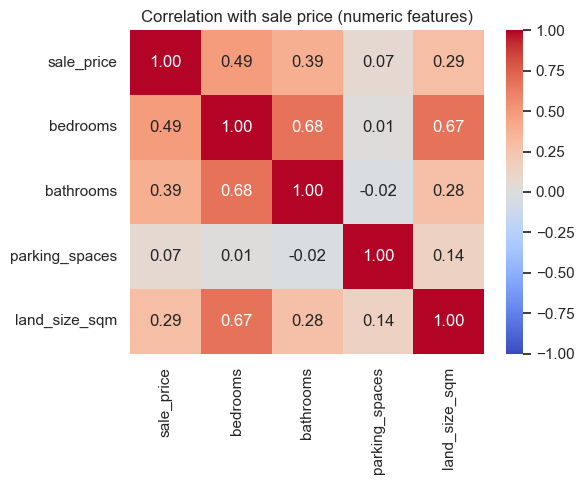

sale_price        1.000000
bedrooms          0.488473
bathrooms         0.386900
land_size_sqm     0.289782
parking_spaces    0.067345
Name: sale_price, dtype: float64


In [18]:
numeric_cols = ['sale_price','bedrooms','bathrooms','parking_spaces','land_size_sqm']
corr = df[numeric_cols].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlation with sale price (numeric features)')
plt.tight_layout()
plt.show()

print(corr['sale_price'].sort_values(ascending=False))

In [19]:
suburb_medians = df.groupby('suburb')['sale_price'].median().sort_values()
print('median price by suburb:')
print(suburb_medians)
print()
print(f"range across suburbs: ${suburb_medians.max() - suburb_medians.min():,.0f}")

median price by suburb:
suburb
Blacktown        675000.0
Marrickville    1186000.0
Paddington      2305000.0
Name: sale_price, dtype: float64

range across suburbs: $1,630,000


`bedrooms` (0.49) is the strongest of the four, then `bathrooms` (0.39), then `land_size_sqm` (0.29), then `parking_spaces` trailing well behind (0.05). So land size is still useful, it is actually the third strongest numeric predictor, but weaker than I first expected and clearly behind bedroom and bathroom count. And none of these numeric features come close to **suburb**, the median price swings by over $1.6M just by which of the three suburbs a property is in, which is a far bigger effect than any of the numeric features individually.

**Revised three-variable hypothesis for what drives price here: suburb, bedrooms, bathrooms.**

Land size still deserves a closer look though, since a 0.29 pooled correlation could be hiding very different relationships suburb by suburb, which is exactly what I check next.

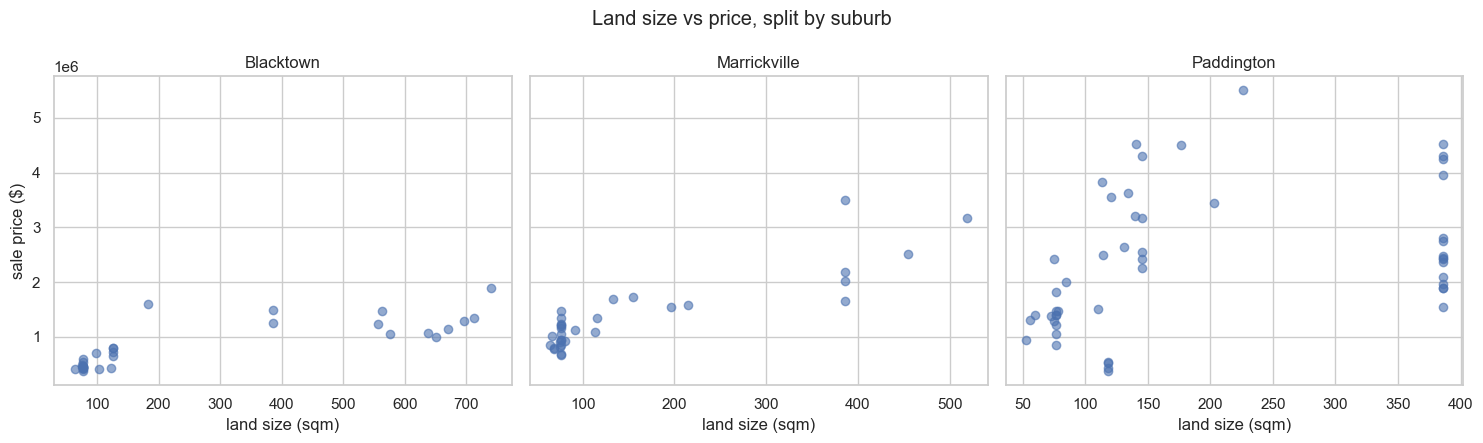

Blacktown: land size vs price correlation = 0.814
Marrickville: land size vs price correlation = 0.879
Paddington: land size vs price correlation = 0.374


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15,4.5), sharey=True)
for ax, suburb in zip(axes, ['Blacktown','Marrickville','Paddington']):
    sub = df[df['suburb']==suburb]
    ax.scatter(sub['land_size_sqm'], sub['sale_price'], alpha=0.6, color='#4C72B0')
    ax.set_title(suburb)
    ax.set_xlabel('land size (sqm)')
axes[0].set_ylabel('sale price ($)')
plt.suptitle('Land size vs price, split by suburb')
plt.tight_layout()
plt.show()

for suburb in ['Blacktown','Marrickville','Paddington']:
    sub = df[df['suburb']==suburb]
    r = sub['land_size_sqm'].corr(sub['sale_price'])
    print(f'{suburb}: land size vs price correlation = {r:.3f}')

This explains the result. Wilimited Blacktown and Marrickville separately, land size correlates strongly with price (0.81 and 0.88), much stronger than I originally expected. Paddington is the outlier here, at 0.37 it is a weaker, more moderate relationship, which matches the earlier boxplot result that Paddington terraces on tiny blocks still sell for millions, location and heritage character carry more of the price there than block size does.

So it was pooling three very different markets together that hid this in the overall correlation number. Land size matters a lot in the two more suburban markets, and much less in the dense inner-city one. Good lesson for Part 3, suburb needs to go into the model, and given how differently land size behaves suburb to suburb, an interaction between suburb and land size might genuinely be worth trying instead of treating land size as having one fixed effect everywhere.

## 2.8 Summary of this section

The price distribution is right-skewed and a log transform looks reasonable to test later. The three suburbs genuinely differ, medians $675K, $1.19M, $2.3M, with very little overlap, which matches the contrast planned in Part 1. `sale_date` cannot be used as a model feature, the actual collection window is only 198 days and suburb and sale month turned out to be strongly confounded (a side effect of how many pages I pulled per suburb), so I am leaving date-based features out of Part 3 entirely instead of risk the model just learning suburb through the back door. Two real outliers exist, both Marrickville houses, and I am keeping them since they are real sales, not errors. Missing values in land size, parking, and bathrooms are now handled (median-by-type for land size and bathrooms; for parking, median-by-type as well except Studio, which has zero observed data of any kind and gets 0 as a stated assumption instead of an evidence-based fill), all three flagged. My revised hypothesis for the three strongest price drivers is suburb, bedrooms, and bathrooms. Land size turned out to matter a lot too, just unevenly across suburbs, which is a more interesting and useful finding than my original flat guess.